# Silver Annotation — SIREVA-SUS NER

Anota as sentenças extraídas dos relatórios SIREVA-SUS com entidades nomeadas usando **GPT-4o-mini** (few-shot).

**Tagset:** PATOGENO · SOROTIPO · FAIXA_ETARIA · LOCAL · PERIODO_TEMPORAL · METODO_LAB · METRICA_EPI · MANIFESTACAO_CLINICA

**Input:** `data/extracted/*.jsonl` (12 relatórios, 2013–2024)  
**Output:** `data/silver/*.jsonl` (tokens + bio_tags + spans)

## 1. Setup

In [1]:
# Instala dependências se necessário
%pip install -q openai python-dotenv

Note: you may need to restart the kernel to use updated packages.


c:\Users\chris\OneDrive\Documentos\Projetos\SIREVA-SUS-Corpus\.venv\Scripts\python.exe: No module named pip


In [7]:
import json
import re
import time
import logging
from pathlib import Path
from collections import Counter
from typing import Any

import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv, find_dotenv
from openai import OpenAI

load_dotenv(find_dotenv(usecwd=True))

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(message)s")
logger = logging.getLogger(__name__)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 11

print("Imports OK")

Imports OK


In [8]:
import os

# Caminhos
PROJECT_ROOT  = Path(".").resolve()
DATA_EXTRACTED = PROJECT_ROOT / "data" / "extracted"
DATA_SILVER    = PROJECT_ROOT / "data" / "silver"
DATA_SILVER.mkdir(parents=True, exist_ok=True)

# API
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY", "")
MODEL = "gpt-4o-mini"

if not OPENAI_API_KEY:
    raise EnvironmentError("OPENAI_API_KEY não encontrada no .env")

client = OpenAI(api_key=OPENAI_API_KEY)

# Relatórios disponíveis
reports = sorted(p.stem for p in DATA_EXTRACTED.glob("*.jsonl"))
print(f"Relatórios encontrados ({len(reports)}): {reports}")

Relatórios encontrados (12): ['sireva_2013', 'sireva_2014', 'sireva_2015', 'sireva_2016', 'sireva_2017', 'sireva_2018', 'sireva_2019', 'sireva_2020', 'sireva_2021', 'sireva_2022', 'sireva_2023', 'sireva_2024']


## 2. Tagset e Prompt

| Tag | Descrição | Exemplos |
|---|---|---|
| `PATOGENO` | Organismo causador | *S. pneumoniae*, meningococo, pneumococo |
| `SOROTIPO` | Classificação sorológica | sorotipo 19A, sorogrupo B, tipo b |
| `FAIXA_ETARIA` | Estratificação etária | menores de 12 meses, ≥60 anos |
| `LOCAL` | Localização geográfica | Brasil, região Sudeste, São Paulo |
| `PERIODO_TEMPORAL` | Delimitação temporal | 2024, semana epidemiológica 35 |
| `METODO_LAB` | Técnica laboratorial | cultura, PCR em tempo real, MALDI-TOF |
| `METRICA_EPI` | Medida epidemiológica (conceito) | taxa de incidência, letalidade, cobertura vacinal |
| `MANIFESTACAO_CLINICA` | Doença ou síndrome | meningite, pneumonia, doença invasiva |

In [9]:
ENTITY_TYPES = [
    {"name": "PATOGENO",           "description": "Organismo causador de doença invasiva (bactérias, vírus, fungos).",
     "examples": ["Streptococcus pneumoniae", "N. meningitidis", "meningococo"]},
    {"name": "SOROTIPO",            "description": "Identificação sorológica específica do patógeno: sorotipo, sorogrupo ou tipo.",
     "examples": ["sorotipo 19A", "sorogrupo B", "tipo b"]},
    {"name": "FAIXA_ETARIA",        "description": "Intervalo etário usado como estratificação epidemiológica.",
     "examples": ["menor que 12 meses", "60 anos ou mais", "lactentes"]},
    {"name": "LOCAL",               "description": "Localização geográfica nomeada (países, estados, municípios, regiões).",
     "examples": ["Brasil", "São Paulo", "região Sudeste"]},
    {"name": "PERIODO_TEMPORAL",    "description": "Delimitação temporal explícita: anos, semanas epidemiológicas, meses.",
     "examples": ["2024", "2013 a 2024", "semana epidemiológica 35"]},
    {"name": "METODO_LAB",          "description": "Técnica laboratorial ou diagnóstica nomeada.",
     "examples": ["cultura", "PCR em tempo real", "MALDI-TOF"]},
    {"name": "METRICA_EPI",         "description": "Medida quantitativa epidemiológica — o conceito, não o valor numérico.",
     "examples": ["taxa de incidência", "número de casos", "letalidade"]},
    {"name": "MANIFESTACAO_CLINICA","description": "Doença, síndrome ou condição clínica nomeada.",
     "examples": ["meningite", "pneumonia", "doença invasiva"]},
]

VALID_ENTITY_NAMES = frozenset(e["name"] for e in ENTITY_TYPES)

print(f"Tagset ({len(ENTITY_TYPES)} categorias): {list(VALID_ENTITY_NAMES)}")

Tagset (8 categorias): ['MANIFESTACAO_CLINICA', 'LOCAL', 'METRICA_EPI', 'FAIXA_ETARIA', 'PATOGENO', 'METODO_LAB', 'PERIODO_TEMPORAL', 'SOROTIPO']


In [10]:
def build_entity_descriptions():
    lines = []
    for et in ENTITY_TYPES:
        exs = ", ".join(f'"{e}"' for e in et["examples"])
        lines.append(f"- {et['name']}: {et['description']} Ex: {exs}")
    return "\n".join(lines)

SYSTEM_PROMPT = f"""\
Você é um anotador especialista em reconhecimento de entidades nomeadas (NER) \
para textos epidemiológicos em português brasileiro.

Sua tarefa: identificar entidades nomeadas em sentenças de relatórios \
epidemiológicos do SIREVA-SUS (vigilância de meningite e pneumonia bacteriana).

Categorias disponíveis:
{build_entity_descriptions()}

Regras:
- Retorne SOMENTE um JSON com a chave "entidades": lista de objetos \
{{"texto": "<trecho exato>", "tipo": "<CATEGORIA>"}}.
- Use apenas as categorias listadas acima.
- O campo "texto" deve ser o trecho EXATO como aparece na sentença.
- Não anote valores numéricos isolados em METRICA_EPI — anote o conceito \
(ex: "taxa de incidência"), não o número.
- Se não houver entidades, retorne {{"entidades": []}}.
"""

FEW_SHOT = [
    {"role": "user",
     "content": 'Sentença: "A taxa de incidência de meningite por Neisseria meningitidis sorogrupo B foi maior na região Sudeste em 2022."'},
    {"role": "assistant",
     "content": json.dumps({"entidades": [
         {"texto": "taxa de incidência",    "tipo": "METRICA_EPI"},
         {"texto": "meningite",             "tipo": "MANIFESTACAO_CLINICA"},
         {"texto": "Neisseria meningitidis","tipo": "PATOGENO"},
         {"texto": "sorogrupo B",           "tipo": "SOROTIPO"},
         {"texto": "região Sudeste",        "tipo": "LOCAL"},
         {"texto": "2022",                  "tipo": "PERIODO_TEMPORAL"},
     ]}, ensure_ascii=False)},
    {"role": "user",
     "content": 'Sentença: "Crianças menores de 5 anos apresentaram maior letalidade por pneumonia pneumocócica sorotipo 19A, diagnosticada por cultura e PCR em tempo real."'},
    {"role": "assistant",
     "content": json.dumps({"entidades": [
         {"texto": "Crianças menores de 5 anos", "tipo": "FAIXA_ETARIA"},
         {"texto": "letalidade",                 "tipo": "METRICA_EPI"},
         {"texto": "pneumonia",                  "tipo": "MANIFESTACAO_CLINICA"},
         {"texto": "pneumocócica",               "tipo": "PATOGENO"},
         {"texto": "sorotipo 19A",               "tipo": "SOROTIPO"},
         {"texto": "cultura",                    "tipo": "METODO_LAB"},
         {"texto": "PCR em tempo real",          "tipo": "METODO_LAB"},
     ]}, ensure_ascii=False)},
    {"role": "user",
     "content": 'Sentença: "O número de casos de doença invasiva por Haemophilus influenzae tipo b em menores de 12 meses aumentou no estado de São Paulo em 2019."'},
    {"role": "assistant",
     "content": json.dumps({"entidades": [
         {"texto": "número de casos",           "tipo": "METRICA_EPI"},
         {"texto": "doença invasiva",           "tipo": "MANIFESTACAO_CLINICA"},
         {"texto": "Haemophilus influenzae",    "tipo": "PATOGENO"},
         {"texto": "tipo b",                    "tipo": "SOROTIPO"},
         {"texto": "menores de 12 meses",       "tipo": "FAIXA_ETARIA"},
         {"texto": "São Paulo",                 "tipo": "LOCAL"},
         {"texto": "2019",                      "tipo": "PERIODO_TEMPORAL"},
     ]}, ensure_ascii=False)},
]

print("Prompt e exemplos few-shot configurados.")
print(f"Exemplos: {len(FEW_SHOT) // 2} (user+assistant pairs)")

Prompt e exemplos few-shot configurados.
Exemplos: 3 (user+assistant pairs)


## 3. Funções de Anotação

In [11]:
def tokenize(text: str) -> tuple[list[str], list[tuple[int, int]]]:
    """Divide texto em tokens com offsets de caractere."""
    tokens, offsets = [], []
    for m in re.finditer(r"\S+", text):
        tokens.append(m.group())
        offsets.append((m.start(), m.end()))
    return tokens, offsets


def spans_to_bio(
    text: str, spans: list[dict[str, str]]
) -> tuple[list[str], list[str]]:
    """Converte spans {texto, tipo} para listas (tokens, bio_tags)."""
    tokens, offsets = tokenize(text)
    bio_tags = ["O"] * len(tokens)

    for span in spans:
        span_text = span.get("texto", "")
        span_type = span.get("tipo", "")
        if not span_text or span_type not in VALID_ENTITY_NAMES:
            continue

        idx = text.find(span_text)
        if idx == -1:
            idx = text.lower().find(span_text.lower())
        if idx == -1:
            continue

        span_end = idx + len(span_text)
        matching = [i for i, (ts, te) in enumerate(offsets) if ts < span_end and te > idx]
        if not matching:
            continue

        bio_tags[matching[0]] = f"B-{span_type}"
        for i in matching[1:]:
            bio_tags[i] = f"I-{span_type}"

    return tokens, bio_tags


def annotate_sentence(text: str) -> tuple[list[dict], list[str], list[str]]:
    """
    Anota uma sentença via GPT-4o-mini.

    Retorna:
        spans     — lista de {texto, tipo}
        tokens    — lista de tokens
        bio_tags  — lista de tags BIO
    """
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        *FEW_SHOT,
        {"role": "user", "content": f'Sentença: "{text}"'},
    ]

    response = client.chat.completions.create(
        model=MODEL,
        messages=messages,
        temperature=0.0,
        response_format={"type": "json_object"},
        max_tokens=512,
    )

    raw = response.choices[0].message.content or "{}"
    try:
        spans = json.loads(raw).get("entidades", [])
    except json.JSONDecodeError:
        spans = []

    tokens, bio_tags = spans_to_bio(text, spans)
    return spans, tokens, bio_tags


print("Funções prontas.")

Funções prontas.


## 4. Teste com uma sentença

In [12]:
texto_teste = (
    "A taxa de incidência de doença pneumocócica invasiva por sorotipo 19A "
    "em crianças menores de 2 anos foi de 3,2 por 100 mil habitantes no Brasil em 2022, "
    "confirmada por cultura e PCR em tempo real."
)

spans, tokens, bio_tags = annotate_sentence(texto_teste)

print(f"Texto: {texto_teste}\n")
print(f"{'Token':<30} {'BIO Tag'}")
print("-" * 50)
for tok, tag in zip(tokens, bio_tags):
    mark = " <<<" if tag != "O" else ""
    print(f"  {tok:<28} {tag}{mark}")

print(f"\nSpans encontrados ({len(spans)}):")
for s in spans:
    print(f"  [{s['tipo']}] {s['texto']}")

INFO Retrying request to /chat/completions in 0.436294 seconds
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Texto: A taxa de incidência de doença pneumocócica invasiva por sorotipo 19A em crianças menores de 2 anos foi de 3,2 por 100 mil habitantes no Brasil em 2022, confirmada por cultura e PCR em tempo real.

Token                          BIO Tag
--------------------------------------------------
  A                            O
  taxa                         B-METRICA_EPI <<<
  de                           I-METRICA_EPI <<<
  incidência                   I-METRICA_EPI <<<
  de                           O
  doença                       B-MANIFESTACAO_CLINICA <<<
  pneumocócica                 I-MANIFESTACAO_CLINICA <<<
  invasiva                     I-MANIFESTACAO_CLINICA <<<
  por                          O
  sorotipo                     B-SOROTIPO <<<
  19A                          I-SOROTIPO <<<
  em                           O
  crianças                     B-FAIXA_ETARIA <<<
  menores                      I-FAIXA_ETARIA <<<
  de                           I-FAIXA_ETARIA <<<
  2       

## 5. Inspecionar dados extraídos

In [13]:
def read_jsonl(path: Path) -> list[dict]:
    with path.open(encoding="utf-8") as f:
        return [json.loads(line) for line in f if line.strip()]


# Conta sentenças por relatório
stats = []
for report in reports:
    sents = read_jsonl(DATA_EXTRACTED / f"{report}.jsonl")
    stats.append({"relatorio": report, "n_sentencas": len(sents)})

df_stats = pd.DataFrame(stats)
print(df_stats.to_string(index=False))
print(f"\nTotal: {df_stats['n_sentencas'].sum():,} sentenças")

  relatorio  n_sentencas
sireva_2013          257
sireva_2014          249
sireva_2015          255
sireva_2016          266
sireva_2017          230
sireva_2018          238
sireva_2019          243
sireva_2020          274
sireva_2021          281
sireva_2022          295
sireva_2023          385
sireva_2024          370

Total: 3,343 sentenças


In [14]:
# Veja exemplos de sentenças de um relatório
REPORT_SAMPLE = "sireva_2022"  # altere para o ano desejado

sents_sample = read_jsonl(DATA_EXTRACTED / f"{REPORT_SAMPLE}.jsonl")

print(f"Primeiras 10 sentenças de {REPORT_SAMPLE}:\n")
for s in sents_sample[:10]:
    print(f"  [{s['sentenca_id']}] p.{s['pagina']}: {s['texto'][:90]}")

Primeiras 10 sentenças de sireva_2022:

  [sireva_2022_s0001] p.1: SECRETARIA DE ESTADO DA SAÚDE COORDENADORIA DE CONTROLE DE DOENÇAS INSTITUTO ADOLFO LUTZ
  [sireva_2022_s0002] p.1: Informação da vigilância das pneumonias e meningites bacterianas
  [sireva_2022_s0003] p.2: Suscetibilidade a penicilina pela produção de beta lactamase de cepas por
  [sireva_2022_s0004] p.3: O  Núcleo  de  Meningites,  Pneumonias  e  Infecções  Pneumocócicas (NMPI), Centro de Bact
  [sireva_2022_s0005] p.3: Nesse  contexto,  o  IAL monitora as características fenotípicas e moleculares dos isolado
  [sireva_2022_s0006] p.3: Os isolados bacterianos são encaminhados ao IAL-Central, localizado na cidade  de  São  Pa
  [sireva_2022_s0007] p.3: No Estado de São Paulo, a vigilância de Neisseria meningitidis , Haemophilus influenzae e 
  [sireva_2022_s0008] p.3: Anualmente, os dados laboratoriais são disponibilizados à comunidade médica, científica e 
  [sireva_2022_s0009] p.3: Essa  vigilância  de  base  labora

## 6. Anotar um relatório (teste)

Antes de rodar todos os 12, anote um único relatório para validar.

In [15]:
REPORT_TO_TEST = "sireva_2022"  # altere para o ano desejado
DELAY = 60 / 500               # 500 RPM — ajuste se necessário

src = DATA_EXTRACTED / f"{REPORT_TO_TEST}.jsonl"
dst = DATA_SILVER    / f"{REPORT_TO_TEST}.jsonl"

sentences = read_jsonl(src)
annotated = []

print(f"Anotando {len(sentences)} sentenças de {REPORT_TO_TEST}...")

for i, sent in enumerate(sentences):
    try:
        spans, tokens, bio_tags = annotate_sentence(sent["texto"])
        record = {**sent, "tokens": tokens, "bio_tags": bio_tags, "spans": spans}
    except Exception as exc:
        logger.error("Erro em %s: %s", sent.get("sentenca_id"), exc)
        tokens, _ = tokenize(sent["texto"])
        record = {**sent, "tokens": tokens, "bio_tags": ["O"] * len(tokens), "spans": []}

    annotated.append(record)
    time.sleep(DELAY)

    if (i + 1) % 50 == 0:
        print(f"  {i + 1}/{len(sentences)} concluídas")

# Salva
with dst.open("w", encoding="utf-8") as f:
    for r in annotated:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")

print(f"\nSalvo: {dst}  ({len(annotated)} registros)")

Anotando 295 sentenças de sireva_2022...


INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completion

  50/295 concluídas


INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completion

  100/295 concluídas


...

  200/295 concluídas


INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completion

  250/295 concluídas


INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completion


Salvo: C:\Users\chris\OneDrive\Documentos\Projetos\SIREVA-SUS-Corpus\data\silver\sireva_2022.jsonl  (295 registros)


## 7. Inspecionar resultado silver

In [16]:
# Mostra as primeiras sentenças com anotações encontradas
silver = read_jsonl(DATA_SILVER / f"{REPORT_TO_TEST}.jsonl")

with_entities = [s for s in silver if any(t != "O" for t in s["bio_tags"])]
print(f"Sentenças com pelo menos 1 entidade: {len(with_entities)}/{len(silver)}\n")

for s in with_entities[:5]:
    print(f"[{s['sentenca_id']}] {s['texto']}")
    for sp in s["spans"]:
        print(f"  → [{sp['tipo']}] {sp['texto']}")
    print()

Sentenças com pelo menos 1 entidade: 67/295

[sireva_2022_s0005] Nesse  contexto,  o  IAL monitora as características fenotípicas e moleculares dos isolados de Neisseria meningitidis , Haemophilus influenzae e Streptococcus pneumoniae isoladas de casos  de  doenças  invasivas  nos  estados  brasileiros  através  da  vigilância nacional de base laboratorial.
  → [PATOGENO] Neisseria meningitidis
  → [PATOGENO] Haemophilus influenzae
  → [PATOGENO] Streptococcus pneumoniae
  → [MANIFESTACAO_CLINICA] doenças invasivas
  → [LOCAL] estados brasileiros

[sireva_2022_s0006] Os isolados bacterianos são encaminhados ao IAL-Central, localizado na cidade  de  São  Paulo,  pela  rede  de  Laboratórios  Centrais  de  Saúde  Pública (LACENs) localizados um em cada estado do Brasil, e coordenada CGLAB e CGDT, Secretaria de Vigilância em Saúde do Ministério da Saúde (SVS, MS).
  → [LOCAL] IAL-Central
  → [LOCAL] São Paulo
  → [LOCAL] Brasil
  → [LOCAL] CGLAB
  → [LOCAL] CGDT
  → [LOCAL] Secretaria de 

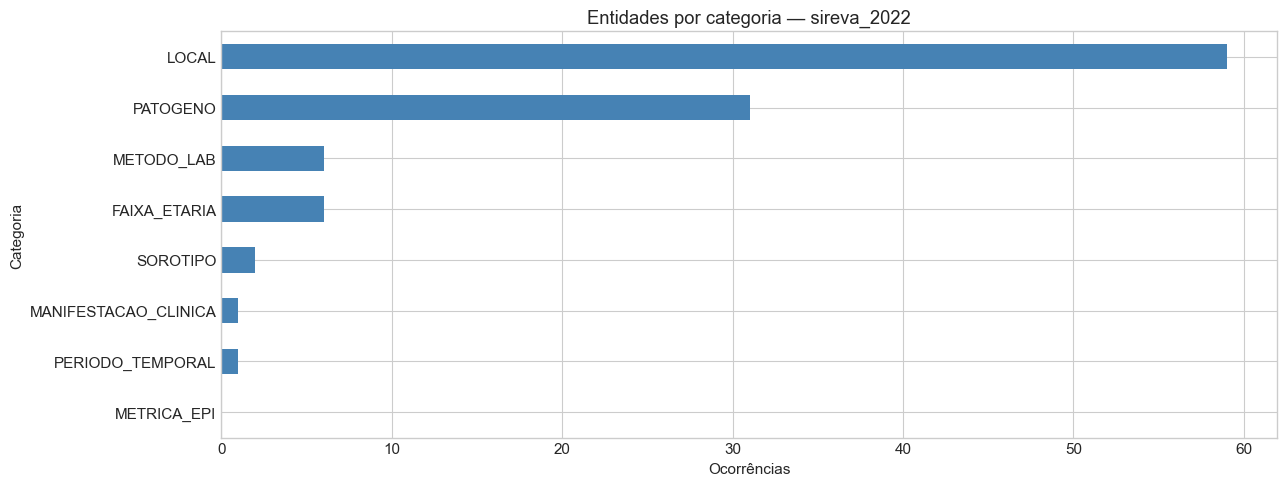

           Categoria  Contagem
               LOCAL        59
            PATOGENO        31
        FAIXA_ETARIA         6
          METODO_LAB         6
            SOROTIPO         2
    PERIODO_TEMPORAL         1
MANIFESTACAO_CLINICA         1
         METRICA_EPI         0
Total: 106


In [17]:
# Distribuição de entidades no relatório anotado
counts = Counter(
    tag[2:] for s in silver for tag in s["bio_tags"] if tag.startswith("B-")
)

df_counts = pd.DataFrame(
    [(cat, counts.get(cat, 0)) for cat in [e["name"] for e in ENTITY_TYPES]],
    columns=["Categoria", "Contagem"]
).sort_values("Contagem", ascending=True)

ax = df_counts.plot.barh(x="Categoria", y="Contagem", legend=False, color="steelblue")
ax.set_title(f"Entidades por categoria — {REPORT_TO_TEST}")
ax.set_xlabel("Ocorrências")
plt.tight_layout()
plt.show()

print(df_counts.sort_values("Contagem", ascending=False).to_string(index=False))
print(f"Total: {df_counts['Contagem'].sum()}")

## 8. Anotar todos os relatórios

> **Execute apenas após validar a célula 6.**  
> Pula relatórios já existentes em `data/silver/`.

In [18]:
DELAY = 60 / 500  # 500 RPM

for report in reports:
    dst = DATA_SILVER / f"{report}.jsonl"
    if dst.exists():
        print(f"[SKIP] {report} (já existe)")
        continue

    sentences = read_jsonl(DATA_EXTRACTED / f"{report}.jsonl")
    annotated = []
    print(f"\nAnotando {report} ({len(sentences)} sentenças)...")

    for i, sent in enumerate(sentences):
        try:
            spans, tokens, bio_tags = annotate_sentence(sent["texto"])
            record = {**sent, "tokens": tokens, "bio_tags": bio_tags, "spans": spans}
        except Exception as exc:
            logger.error("Erro em %s: %s", sent.get("sentenca_id"), exc)
            tokens, _ = tokenize(sent["texto"])
            record = {**sent, "tokens": tokens, "bio_tags": ["O"] * len(tokens), "spans": []}

        annotated.append(record)
        time.sleep(DELAY)

        if (i + 1) % 50 == 0:
            print(f"  {i + 1}/{len(sentences)}")

    with dst.open("w", encoding="utf-8") as f:
        for r in annotated:
            f.write(json.dumps(r, ensure_ascii=False) + "\n")

    print(f"  Salvo: {dst}")

print("\nConcluído.")


Anotando sireva_2013 (257 sentenças)...


INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completion

  50/257


INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completion

  100/257


...

  300/370


INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completion

  350/370


INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO HTTP Request: POST https://api.openai.com/v1/chat/completion

  Salvo: C:\Users\chris\OneDrive\Documentos\Projetos\SIREVA-SUS-Corpus\data\silver\sireva_2024.jsonl

Concluído.


## 9. Visão geral — todos os relatórios anotados

In [19]:
silver_files = sorted(DATA_SILVER.glob("*.jsonl"))

if not silver_files:
    print("Nenhum arquivo silver ainda.")
else:
    rows = []
    for sf in silver_files:
        recs = read_jsonl(sf)
        total_ents = sum(1 for r in recs for t in r["bio_tags"] if t.startswith("B-"))
        with_ents  = sum(1 for r in recs if any(t != "O" for t in r["bio_tags"]))
        rows.append({"relatorio": sf.stem, "sentencas": len(recs),
                     "com_entidades": with_ents, "total_entidades": total_ents})

    df = pd.DataFrame(rows)
    df["cobertura_%"] = (df["com_entidades"] / df["sentencas"] * 100).round(1)
    print(df.to_string(index=False))
    print(f"\nTotal de entidades: {df['total_entidades'].sum():,}")
    print(f"Total de sentenças: {df['sentencas'].sum():,}")

  relatorio  sentencas  com_entidades  total_entidades  cobertura_%
sireva_2013        257             57               84         22.2
sireva_2014        249             52               75         20.9
sireva_2015        255             53               79         20.8
sireva_2016        266             61               86         22.9
sireva_2017        230             52               70         22.6
sireva_2018        238             48               69         20.2
sireva_2019        243             55               79         22.6
sireva_2020        274             69              104         25.2
sireva_2021        281             66              100         23.5
sireva_2022        295             67              106         22.7
sireva_2023        385            107              155         27.8
sireva_2024        370             85              132         23.0

Total de entidades: 1,139
Total de sentenças: 3,343


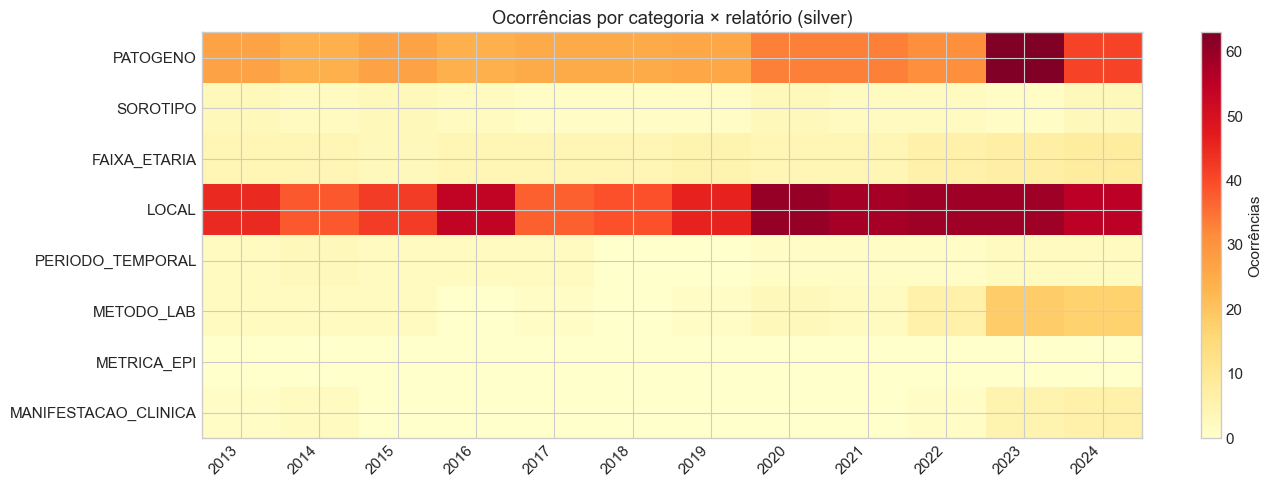

In [20]:
# Heatmap: entidades por categoria × relatório
if silver_files:
    entity_names = [e["name"] for e in ENTITY_TYPES]
    matrix = {}

    for sf in silver_files:
        recs = read_jsonl(sf)
        c = Counter(t[2:] for r in recs for t in r["bio_tags"] if t.startswith("B-"))
        matrix[sf.stem.replace("sireva_", "")] = {cat: c.get(cat, 0) for cat in entity_names}

    df_heat = pd.DataFrame(matrix).T

    fig, ax = plt.subplots(figsize=(14, 5))
    im = ax.imshow(df_heat.values.T, aspect="auto", cmap="YlOrRd")
    ax.set_xticks(range(len(df_heat.index)))
    ax.set_xticklabels(df_heat.index, rotation=45, ha="right")
    ax.set_yticks(range(len(entity_names)))
    ax.set_yticklabels(entity_names)
    ax.set_title("Ocorrências por categoria × relatório (silver)")
    plt.colorbar(im, ax=ax, label="Ocorrências")
    plt.tight_layout()
    plt.show()